In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import scipy
import statsmodels
import pyreadstat
import numpy as np
from scipy.stats import norm

In [2]:
#You can change the name of the database
filename="asthma_best_db.sav"

In [3]:
#The following block of code will allow for the creation of an dynamic path regardless of the computer the script is running on
current_dir=os.getcwd()
d2s1_folder=os.path.dirname(current_dir)
bd_path="data/raw"

In [4]:
#Now we create a personalized absolute path for the database
db_full_path=os.path.join(d2s1_folder, bd_path,filename)
print (db_full_path)

/Users/danielmdias/docs/5.homelab/code/PCDS2026WS/d2s1/data/raw/asthma_best_db.sav


In [ ]:
#We create a new object called my_df. Now we create a personalized absolute path for the database
df, meta = pyreadstat.read_sav(db_full_path)

We will demonstrate the export to xslx and csv and reimport

In [10]:
df.to_excel(os.path.join(d2s1_folder,'data/processed/db_in_excel.xlsx'))
df.to_csv(os.path.join(d2s1_folder,'data/processed/db_in_csv.csv'))

In [11]:
df_new=pd.read_csv(os.path.join(d2s1_folder,'data/processed/db_in_csv.csv'))

In [15]:
def get_labels():
    for var, label_set_name in meta.variable_to_label.items():
        if label_set_name in meta.value_labels:
            print(f"{var} → {meta.value_labels[label_set_name]}")

In [16]:
get_labels()

RIAGENDR → {1.0: 'Masculino', 2.0: 'Feminino'}
raca_etnia → {1.0: 'Hispânicos', 2.0: 'Caucasianos', 3.0: 'Negros', 4.0: 'Asiáticos'}
MCQ010 → {1.0: 'Sim', 2.0: 'Não', 7.0: 'Não sei / Não respondo', 9.0: 'Não respondeu'}


Now we define most common metrics for decision for continuous variables

In [24]:
def get_mean_and_std(column_name, number_of_decimals):
    result_mean=round(df[f"{column_name}"].mean(),number_of_decimals)
    result_sd=round(df[f"{column_name}"].std(),number_of_decimals)
    result=f"{result_mean} [{result_sd}]"
    return result

In [25]:
def get_median_and_iqr(column_name, number_of_decimals):
    result_median=round(df[f"{column_name}"].median(),number_of_decimals)
    result_q1=round(df[f"{column_name}"].quantile(0.25),number_of_decimals)
    result_q3=round(df[f"{column_name}"].quantile(0.75),number_of_decimals)
    result=f"{result_median} [{result_q1}-{result_q3}]"
    return result

Now we define most common metrics for frequencies

In [26]:
def get_abs_freq_per_category(column_name):
    result = df[f"{column_name}"].value_counts(dropna=False)
    return result

In [35]:
def get_relative_freq_per_category(column_name):
    result = df[column_name].value_counts(normalize=True, dropna=False)*100
    return result

print (get_abs_freq_per_category("AGQ030"))

AGQ030
 2.0    744
 1.0     94
NaN      47
 9.0      3
Name: count, dtype: int64


In [36]:
#example for one variable 
print (get_mean_and_std("SPXNFEV1",2))
print (get_median_and_iqr("SPXNFEV1",2))
print (get_abs_freq_per_category("SMQ040"))
print (get_relative_freq_per_category("SMQ040"))
print ("......................................")

2959.1 [984.66]
2998.5 [2227.25-3614.25]
SMQ040
NaN     636
 3.0    118
 1.0    107
 2.0     27
Name: count, dtype: int64
SMQ040
NaN     71.621622
 3.0    13.288288
 1.0    12.049550
 2.0     3.040541
Name: proportion, dtype: float64
......................................


we will copy the previosuly elaborated categorical list 

In [21]:
categorical_list=[
    "RIAGENDR",
    "raca_etnia",
    "ENQ100",
    "MCQ010",
    "RDQ031",
    "RDQ050",
    "RDQ070", 
    "RDQ090",
    "RDQ100",
    "RDQ140", 
    "AGQ030", 
    "SMQ020",
    "SMQ040"
]

In [22]:
# and convert them to categorical
for i in categorical_list:
    df[f"{i}"]= pd.Categorical(df[f"{i}"])

In [38]:
# for each variable in the dataset, assess whether it is categorical or not and present the appropriate summary
for column in df.columns:
    is_cat = isinstance(df[f"{column}"].dtype, pd.CategoricalDtype)
    if is_cat:
        result1=get_abs_freq_per_category(f"{column}")
        result2=get_relative_freq_per_category(f"{column}")
        print(result1)
        print(result2)
    else:
        print ('Mean (SD): ', get_mean_and_std(f"{column}",1))
        print ('Median (IQR): ',get_median_and_iqr(f"{column}",1))

Mean (SD):  51689.3 [5812.7]
Median (IQR):  51586.5 [46858.2-56589.2]
RIAGENDR
2.0    450
1.0    438
Name: count, dtype: int64
RIAGENDR
2.0    50.675676
1.0    49.324324
Name: proportion, dtype: float64
Mean (SD):  377.0 [283.6]
Median (IQR):  327.5 [119.8-620.0]
raca_etnia
2.0    382
1.0    303
3.0    203
Name: count, dtype: int64
raca_etnia
2.0    43.018018
1.0    34.121622
3.0    22.860360
Name: proportion, dtype: float64
Mean (SD):  3.9 [1.8]
Median (IQR):  4.0 [3.0-5.0]
Mean (SD):  63.4 [33.2]
Median (IQR):  66.6 [38.5-84.6]
Mean (SD):  157.0 [23.3]
Median (IQR):  162.8 [151.9-172.4]
Mean (SD):  26.1 [7.8]
Median (IQR):  25.7 [20.3-30.3]
Mean (SD):  13.9 [1.6]
Median (IQR):  13.8 [12.8-14.9]
Mean (SD):  40.2 [4.4]
Median (IQR):  40.1 [37.1-43.4]
ENQ100
 2.0    487
NaN     270
 1.0    131
Name: count, dtype: int64
ENQ100
 2.0    54.842342
NaN     30.405405
 1.0    14.752252
Name: proportion, dtype: float64
Mean (SD):  17.0 [14.2]
Median (IQR):  13.0 [8.5-20.0]
MCQ010
 2.0    719
 1

create a new categorical variable from cutpoints

In [41]:
df["Age_at_diagnosis_cat"] = pd.cut(df["MCQ025"], bins=[0, 18, 65, np.inf], labels=["Young", "Adult", "Senior"])
print(get_abs_freq_per_category("Age_at_diagnosis_cat"))




Age_at_diagnosis_cat
NaN       766
Young      97
Adult      24
Senior      1
Name: count, dtype: int64


In [ ]:
# apply some transformation to every row in a column
# FEV1 in mL to L (PS: not usually used)
df["FEV1_L"] = df["SPXNFEV1"].apply(lambda x: x / 1000)
print("FEV1_L")
print(get_mean_and_std("FEV1_L",2))

FEV1_L
2.96 [0.98]


In [44]:
# create a new categorical variable from cutpoints with conditional
def anemia_status(row):
    if row["RIAGENDR"] == 1:
        cut = 13
    elif row["RIAGENDR"] == 2:
        cut = 12
    else:
        return np.nan  
    return "Yes" if row["LBXHGB"] < cut else "No"

In [45]:
df["Anemia_cat"] = df.apply(anemia_status, axis=1)

In [46]:
print(get_abs_freq_per_category("Anemia_cat"))

Anemia_cat
No     786
Yes    102
Name: count, dtype: int64


Now we want to plot the different variables. Let's see some examples

# Countplot com subdivisão por Sexo
sns.countplot(data=df, x="Anemia_cat")
plt.title("Contagem de Anemia por Sexo")
plt.ylabel("Quantidade")
plt.xlabel("Anemia")
plt.show()

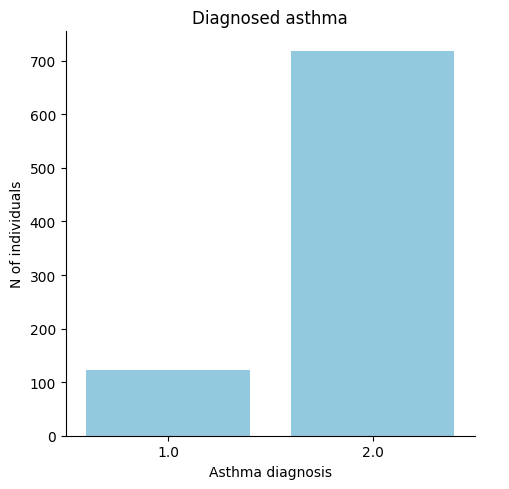

In [48]:
# Bar plot for asthma categorized
graph1=sns.catplot(
    data=df,
    x="MCQ010",
    kind="count", 
    color="skyblue" # ou "bar" para valores numéricos
).set(
    title="Diagnosed asthma",
    xlabel="Asthma diagnosis",
    ylabel="N of individuals"
)
graph1.tight_layout()
plt.show()

create a function for new variables

In [53]:
def get_graph_bar(df,variable,x,y,title):
    graph=sns.catplot(
        data=df,
        x=variable,
        kind="count", 
        color="skyblue" # ou "bar" para valores numéricos
    ).set(
        title=title,
        xlabel=x,
        ylabel=y
    )
    graph.tight_layout()
    plt.savefig(f"{d2s1_folder}/outputs/figures/graph_bar_{variable}.png", dpi=300, bbox_inches='tight')
    plt.show()
    return None

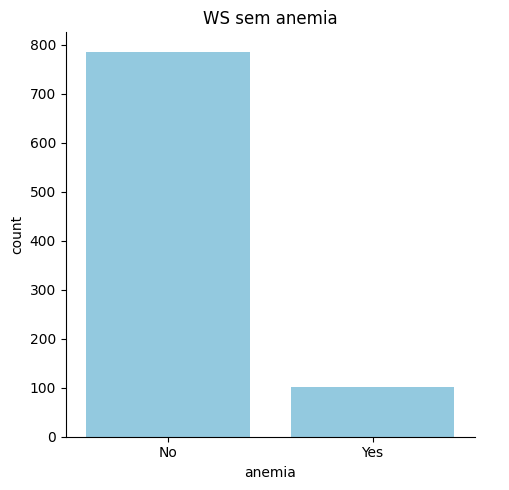

In [54]:
get_graph_bar(df,"Anemia_cat","anemia","count","WS sem anemia")

In [52]:
counts = df["Anemia_cat"].value_counts()

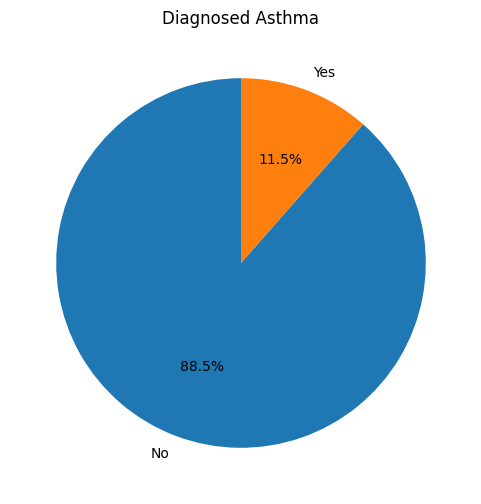

In [ ]:
plt.figure(figsize=(6,6))
plt.pie(
    counts,
    labels=counts.index,
    autopct="%1.1f%%",
    startangle=90,
)
plt.title("Diagnosed Asthma")
plt.savefig(f"{d2s1_folder}/outputs/figures/pie_anemia_cat.png", dpi=300, bbox_inches='tight')
plt.show()

In [56]:
def get_hisplot(df,variable,x,title,bins, normality_curve):
    sns.histplot(
        data=df,
        x=variable,    # coluna numérica
        bins=bins,         # número de barras
        kde=False,       # True se quiser curva de densidade
        stat="density",
        color="skyblue"  # cor das barras
    ).set(
        title=title,
        xlabel=x,
    )
    if normality_curve:
        xmin, xmax = df[f"{variable}"].min(), df[f"{variable}"].max()
        x = np.linspace(xmin, xmax, 100)
        p = norm.pdf(x, df[f"{variable}"].mean(), df[f"{variable}"].std())
        plt.plot(x, p, 'r', lw=2)  #r for red
    plt.savefig(f"{d2s1_folder}/outputs/figures/hist_{variable}.png", dpi=300, bbox_inches='tight')
    plt.show()

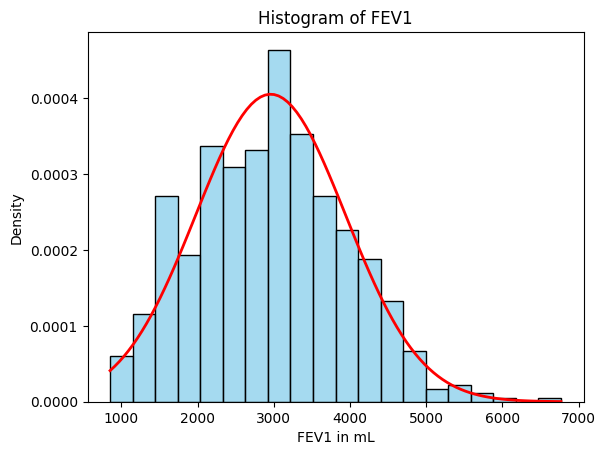

In [57]:
get_hisplot(df,"SPXNFEV1","FEV1 in mL", "Histogram of FEV1", 20, True)

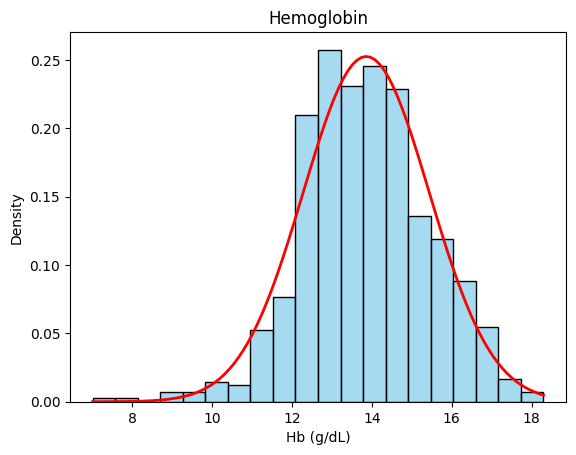

In [59]:
get_hisplot(df,"LBXHGB","Hb (g/dL)", "Hemoglobin", 20, True)